
# Data Mining Assignment 4 – Classification
## Task 2: Model Explainability

---
### 0. Import & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import json
import re
import scipy.sparse
import pickle
import shap

# paths creation need to adapt with yours
path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A4' 

data_path = os.path.join(path, 'datas')
preprocessed = os.path.join(path, 'preprocessed')
figures = os.path.join(path, 'fig')
os.makedirs(figures, exist_ok=True)

INCOME_PATH = os.path.join(data_path,'income.csv')

SEED = 42
print('Imported and paths created')


Imported and paths created


---
### 1. Loading datas

In [2]:
# load model
rf = pickle.load(open(os.path.join(preprocessed, 'model_rf.pkl'), 'rb'))

# load data
X_train = pd.read_csv(os.path.join(preprocessed, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(preprocessed, 'X_test.csv'))

# ensure X_test columns match exactly what the model was trained on
X_test = X_test[rf.feature_names_in_]
FEATURES = list(rf.feature_names_in_)

print(f"--- Model: RF | Trees: {rf.n_estimators} | Max Depth: {rf.max_depth} ---")
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Columns Match: {list(X_train.columns) == list(X_test.columns)}")
print("\n--- X_train Head ---")
print(X_train.head())

--- Model: RF | Trees: 200 | Max Depth: None ---
Train: (7200, 29) | Test: (1800, 29) | Columns Match: True

--- X_train Head ---
   age  education  workinghours  birth_bin  workclass_no paid work  \
0   30         19            40          0                   False   
1   42         19            40          0                   False   
2   58         21            37          0                   False   
3   48         10            40          0                   False   
4   36         24            45          0                   False   

   workclass_private  workclass_self employed  marital status_Husband  \
0               True                    False                    True   
1              False                    False                    True   
2              False                    False                   False   
3               True                    False                   False   
4              False                    False                    True   

   marital

---
### 3. SHAP

In [4]:
print(f"shap_vals_high shape : {shap_vals_high.shape}")
print(f"X_test shape         : {X_test.shape}")
print(f"shap_values type     : {type(shap_values)}")
print(f"len(shap_values)     : {len(shap_values)}")
if isinstance(shap_values, list):
    print(f"shap_values[0] shape : {shap_values[0].shape}")
    print(f"shap_values[1] shape : {shap_values[1].shape}")

shap_vals_high shape : (29, 2)
X_test shape         : (1800, 29)
shap_values type     : <class 'numpy.ndarray'>
len(shap_values)     : 1800


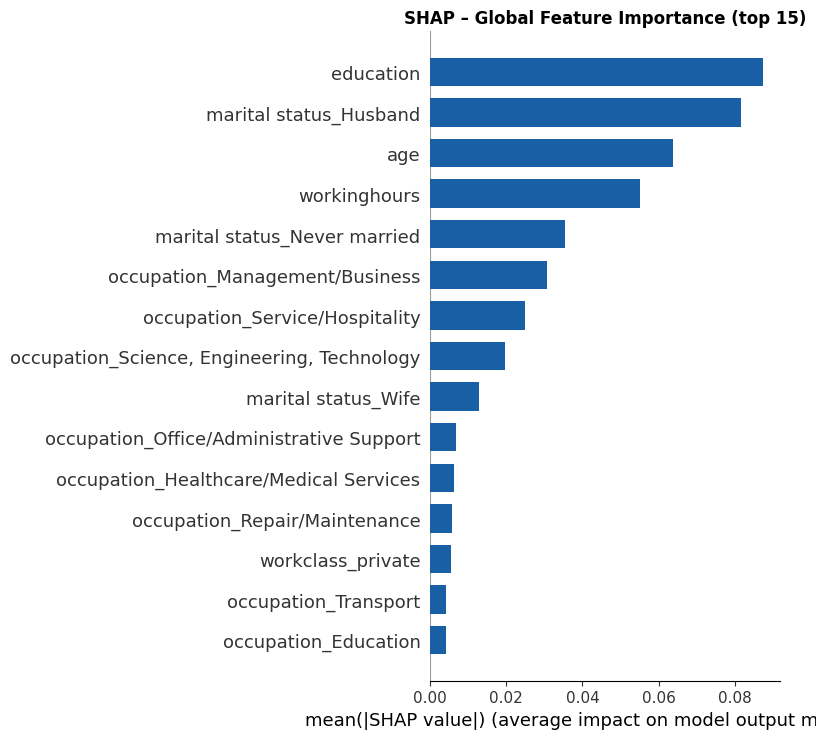

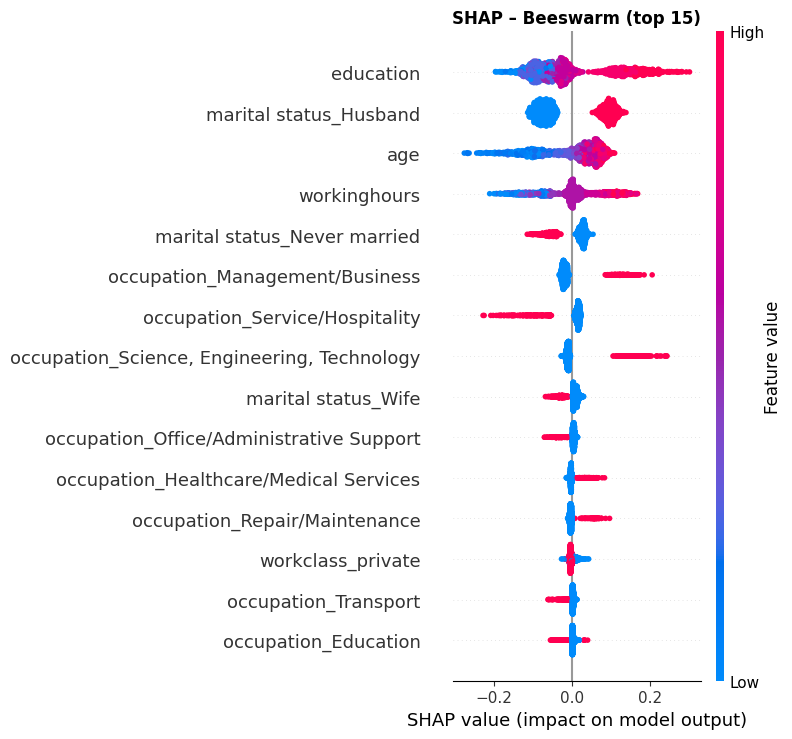

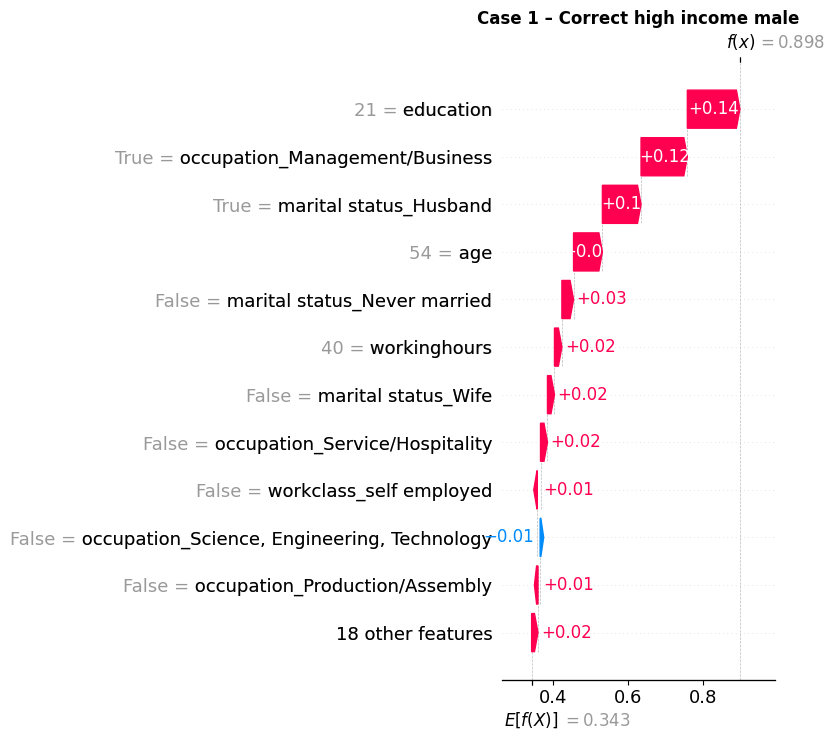

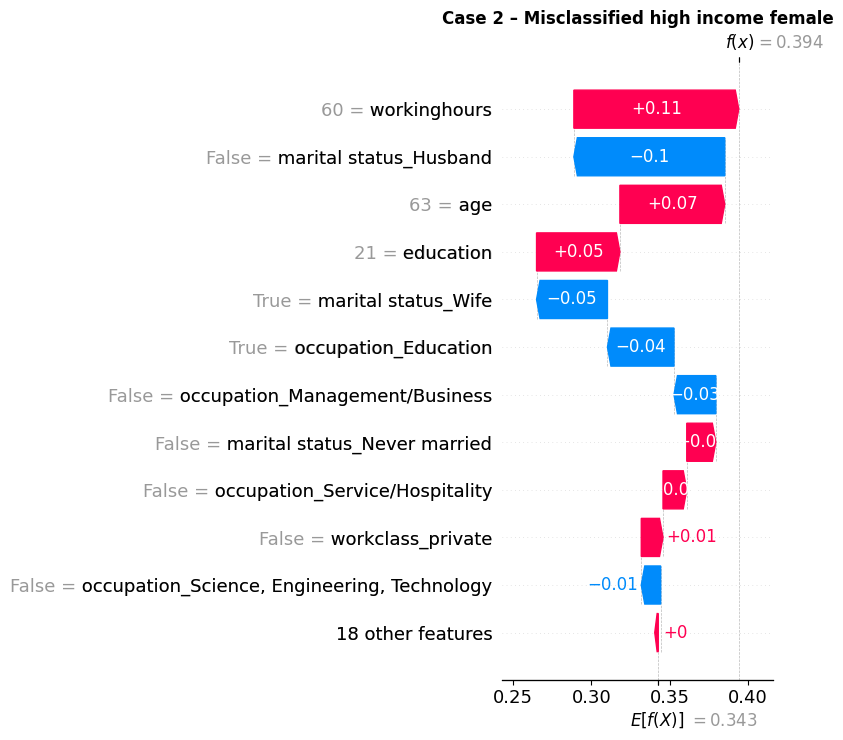

In [6]:
explainer      = shap.TreeExplainer(rf)
shap_values    = explainer.shap_values(X_test)
shap_vals_high = shap_values[:, :, 1]   # 3D array → class 1
base_value     = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_high, X_test, plot_type='bar',
                  feature_names=FEATURES, show=False, max_display=15, color='#185FA5')
plt.title('SHAP – Global Feature Importance (top 15)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(shap_viz, '01_shap_global_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_high, X_test, feature_names=FEATURES, show=False, max_display=15)
plt.title('SHAP – Beeswarm (top 15)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(shap_viz, '02_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

mask_male     = (sex_test == 'Male').values
mask_high     = (y_test == 1).values
correct_preds = (rf.predict(X_test) == y_test.values)
case1_idx     = np.where(mask_male & mask_high & correct_preds)[0][0]

plt.figure(figsize=(10, 4))
shap.waterfall_plot(shap.Explanation(
    values        = shap_vals_high[case1_idx],
    base_values   = base_value,
    data          = X_test.iloc[case1_idx].values,
    feature_names = FEATURES), show=False, max_display=12)
plt.title('Case 1 – Correct high income male', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(shap_viz, '03_shap_case1.png'), dpi=150, bbox_inches='tight')
plt.show()

mask_female = (sex_test == 'Female').values
case2_idx   = np.where(mask_female & mask_high & ~correct_preds)[0][0]

plt.figure(figsize=(10, 4))
shap.waterfall_plot(shap.Explanation(
    values        = shap_vals_high[case2_idx],
    base_values   = base_value,
    data          = X_test.iloc[case2_idx].values,
    feature_names = FEATURES), show=False, max_display=12)
plt.title('Case 2 – Misclassified high income female', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(shap_viz, '04_shap_case2.png'), dpi=150, bbox_inches='tight')
plt.show()